# A mechanism→direction law: a functional melanin screen predicts the *direction* of Mendelian pigmentation disorders

## TL;DR

**What this establishes.** A simple, testable rule that ties three independent evidence layers together:

> *A gene that is a **positive regulator of melanin** (its loss reduces pigment), when mutated by a
> **loss-of-function** allele, causes **hypo**pigmentation; a **negative** regulator causes
> **hyper**pigmentation. The rule is only defined under a loss-of-function allele (recessive / X-linked).*

Tested on genes shared between the **Bajpai 2023 CRISPR melanin-content screen** (functional, in melanocytes),
the **melanocyte gene-regulatory network** (NB6), the **signed–directed melanogenesis network** (NB7), and the
**D'Arcy 2023 OMIM pigmentation-disorder set** (clinical), the rule holds for **22 / 22** recessive/X-linked
genes with a direction call — against a loss-of-function base rate of only 54 % hypopigmentation
(permutation *p* < 1×10⁻⁵). Every dominant "exception" is explained by a **non-loss-of-function** mechanism
(gain-of-function, dominant-negative, proliferative, or non-melanocyte-autonomous), and *TYR* demonstrates the
rule's mechanism-dependence within a single gene — recessive *TYR* loss causes OCA1 albinism (hypo,
concordant), while the dominant *TYR* entry is a proliferative melanoma-susceptibility allele (hyper).

**Why it matters for the project.** This is the project's convergence thesis made *directional and predictive*
on the cleanest available substrate. Where the GWAS rescue screen (NB4–NB8) asks *"does this locus connect to
melanogenesis?"*, this notebook asks a sharper question the network's **sign** can answer: *"which way does the
phenotype go, and when can we trust that prediction?"* The answer — *only under a loss-of-function allele* —
is itself the finding: it names the exact condition under which mechanistic sign transfers to clinical
outcome, and the exact conditions under which it must not be trusted.

**What this is not.** Not a powered association test — *n* is small (22 loss-of-function genes with a direction
call; 13 dominant). It is a **hypothesis-strength law** with a transparent mechanism and enumerated exceptions.
The six dominant discordances are reported in full, not hidden.


> **Key terms**
>
> - **Positive / negative regulator of melanin** — a gene whose loss *reduces* pigment is a positive regulator; one whose loss *increases* pigment is a negative regulator. This notebook's whole test is whether that regulator sign predicts the direction of the disease.
> - **Loss-of-function (LoF) allele** — a disease variant that breaks the gene (here inferred from recessive / X-linked inheritance); it is exactly what a knockout/knockdown screen models, which is why the rule is asserted *only* for LoF alleles.
> - **Bajpai 2023 CRISPR screen / casTLE effect** — a genome-wide CRISPR screen (Bajpai et al. 2023, *Science*) that measured each gene's effect on melanin content in melanocytes; the casTLE effect is its effect size, and every gene in its hit table is a positive regulator (knocking it out reduces melanin).
> - **GRN / regulon (NB6)** — a gene-regulatory network of signed transcription-factor→target edges. Here it is the MITF/SOX10/PAX3 regulons (the genes those melanocyte master TFs activate or repress), curated from the DoRothEA/CollecTRI databases in an upstream notebook (NB6). A gene an activator turns on counts as a positive regulator.
> - **Signed–directed melanogenesis network (NB7)** — the melanin-making pathway rebuilt as a *directed* graph with activation/repression *signs* on each edge (Raghunath et al. 2015 backbone; NB1/NB7). Its "melanin-effector core" is the output hub (TYR, TYRP1, DCT, PMEL, MLANA, SLC45A2, OCA2, SLC24A5); a gene's regulator sign is the product of edge signs along the shortest directed path to that core.
> - **D'Arcy 2023 OMIM set** — a curated list of Mendelian (single-gene) pigmentation-disorder genes from OMIM, each tagged with phenotype direction (hyper/hypo) and inheritance mode; this is the clinical "ground truth" the rule is tested against.
> - **Convergence thesis / rescue screen (NB4–NB8)** — a genotype→pigmentation link is trustworthy when independent evidence lines agree. The rescue screen (NB4–NB8) used it to decide *which* gene a GWAS locus acts through; this notebook extends it to predict *which direction* the phenotype moves once the gene and its allele class are known.



> **⚠️ Read this before the numbers — what "22/22" does and doesn't mean.**
>
> The rule below is a **methodological demonstration, not a discovery about pigmentation biology.** Three limits belong up front, not buried:
>
> - **Largely textbook / near-circular.** "Loss of a positive melanin regulator → hypopigmentation" is close to the *definition* of oculocutaneous albinism. For melanin-synthesis and melanosome genes, the CRISPR "positive-regulator" call and the recessive-disease phenotype are two readouts of the *same* underlying fact — that this gene is required to make melanin — so their agreement is closer to definitional than to an independent prediction.
> - **The 54% base rate flatters the comparison.** It treats *hyper*pigmentation as the symmetric opposite of *hypo*. It is not: there is **no single-gene human "melanism,"** and Mendelian hyperpigmentation is a heterogeneous grab-bag (proliferation, mis-migration, keratinocyte-driven, endocrine) rather than "the melanin dial turned up." So hypo-vs-hyper is not a fair coin-flip null on one axis, and "beating 54%" reads as stronger than it is.
> - **All rare Mendelian disease.** This says nothing about normal pigmentation variation or its evolution.
>
> **What is genuinely ours is narrow and methodological:** a *single* functional readout organizes the *direction* of a whole Mendelian disease category against a quantified null, and its failures are non-random (they concentrate in systemic-route genes). The full literature audit, the *n* = 4 failure-boundary account, and the explicit *"do **not** dress this up as a new law of pigmentation genetics"* live in **[NB12 · Direction law, expanded](12_direction_law_expanded.ipynb)** — read the two together.


## Methods overview

1. **Setup & frozen-input assertions** — resolve repo paths and assert every processed input this notebook
   consumes is on disk.
2. **The clinical layer** — D'Arcy 2023 OMIM pigmentation disorders, restricted to a clear hyper/hypo
   direction, with inheritance mode → a `loss-of-function` flag (recessive AR / X-linked).
3. **Three independent direction layers** — for each gene, an independent "positive vs negative melanin
   regulator" call from (a) the Bajpai CRISPR screen, (b) the NB6 GRN activation/repression sign, and (c) the
   NB7 signed–directed net-sign of the shortest path to the melanin core. Consolidate by majority vote.
4. **Test the law** — predict direction from the regulator call under the loss-of-function condition; measure
   concordance; compare to the loss-of-function base rate with a permutation test and a Fisher exact
   loss-of-function-vs-dominant contrast.
5. **The exceptions are the mechanism** — enumerate every dominant discordance and its documented non-LoF
   mechanism; show *TYR* as the within-gene allelic-series proof.
6. **Limits & relation to the rest of the project.**

**Offline-reproducible:** every input is a committed `data/processed/*.csv`; no live network calls.


In [1]:
import datetime
from pathlib import Path
import numpy as np
import pandas as pd
import networkx as nx
from scipy.stats import fisher_exact

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROC = ROOT / "data" / "processed"

# --- Required input files ---
REQUIRED = {
    "omim":   PROC / "darcy2023_S1_disease_genes.csv",
    "bajpai": PROC / "nb5_bajpai_bipartite_melanin_endpoint.csv",
    "grn":    PROC / "nb6_grn_edges.csv",
    "edges":  PROC / "nb7_substrate_edges.csv",
}
missing = {k: str(p) for k, p in REQUIRED.items() if not p.exists()}
assert not missing, f"Missing committed inputs (cannot re-run): {missing}"
print("All", len(REQUIRED), "frozen inputs present:")
for k, p in REQUIRED.items():
    print(f"  {k:8s} {p.relative_to(ROOT)}")
print("\nRun:", datetime.datetime.now(datetime.timezone.utc).strftime("%Y-%m-%dT%H:%MZ"))


All 4 frozen inputs present:
  omim     data/processed/darcy2023_S1_disease_genes.csv
  bajpai   data/processed/nb5_bajpai_bipartite_melanin_endpoint.csv
  grn      data/processed/nb6_grn_edges.csv
  edges    data/processed/nb7_substrate_edges.csv

Run: 2026-07-12T06:54Z


## Step 2 — The clinical layer: OMIM pigmentation disorders with a direction and an allele class

D'Arcy et al. 2023 (PMC9854651) curated Mendelian pigmentation-disorder genes from OMIM, each classified by
phenotype direction (`phenotype_class` ∈ {Hyperpigmentation, Hypopigmentation, Mixed, …}) and inheritance.
We keep genes with an unambiguous **hyper** or **hypo** direction and derive a **loss-of-function** flag:
autosomal-recessive (`AR`) or X-linked (`XL`) inheritance implies the disease allele acts by loss of function,
which is exactly what a knockdown/knockout screen models. Dominant / congenital / acquired entries are kept
separately — the law is *not* asserted to hold for them, and Step 5 shows why.

In [2]:
s1 = pd.read_csv(REQUIRED["omim"])
dis = (s1[s1["phenotype_class"].isin(["Hyperpigmentation", "Hypopigmentation"])]
       .drop_duplicates("gene").copy())
dis["is_LoF"] = dis["inheritance"].str.contains("AR", na=False) | dis["inheritance"].str.contains("XL", na=False)
dis = dis[["gene", "disease_name", "inheritance", "phenotype_mim", "phenotype_class", "is_LoF"]].reset_index(drop=True)

print(f"OMIM genes with a clear hyper/hypo direction: {len(dis)}")
print("  direction:", dis["phenotype_class"].value_counts().to_dict())
print("  loss-of-function (AR/XL):", int(dis["is_LoF"].sum()), "| dominant/other:", int((~dis["is_LoF"]).sum()))
base_hypo = (dis.loc[dis["is_LoF"], "phenotype_class"] == "Hypopigmentation").mean()
print(f"\nBase rate among LoF genes  P(hypopigmentation) = {base_hypo:.3f}  "
      f"({(dis.loc[dis['is_LoF'],'phenotype_class']=='Hypopigmentation').sum()}/{int(dis['is_LoF'].sum())})")
print("  -> direction is NOT trivially predictable; a rule must beat ~0.54.")


OMIM genes with a clear hyper/hypo direction: 200
  direction: {'Hypopigmentation': 126, 'Hyperpigmentation': 74}
  loss-of-function (AR/XL): 72 | dominant/other: 128

Base rate among LoF genes  P(hypopigmentation) = 0.542  (39/72)
  -> direction is NOT trivially predictable; a rule must beat ~0.54.


## Step 3 — Three independent "positive vs negative melanin regulator" layers

We assemble a direction call for each gene from three sources that are **mechanistically independent** of the
clinical phenotype:

- **(a) Bajpai 2023 CRISPR screen** — every gene in the melanin-content hit table is a *positive* regulator
  (knockdown/knockout reduces melanin; `edge_weight_castle_effect > 0`). Functional, cell-based, and blind to
  the human clinical record.
- **(b) GRN sign (NB6)** — a target that the melanocyte master TFs (MITF / SOX10 / PAX3) *activate* is a
  positive regulator of the pigment program; a *repressed* target is negative.
- **(c) Signed–directed network (NB7)** — the product of edge signs along the shortest directed path from the
  gene to the melanin-effector core (TYR, TYRP1, DCT, PMEL, MLANA, SLC45A2, OCA2, SLC24A5). A net-positive
  path = positive regulator.

We consolidate by majority vote into `regulator_call` ∈ {positive, negative}. Coverage is additive: a gene
counted by any source enters the test.

In [3]:
# (a) Bajpai CRISPR positive regulators
bip = pd.read_csv(REQUIRED["bajpai"])
baj_pos = set(bip["source_gene"])
baj_eff = bip.set_index("source_gene")["edge_weight_castle_effect"].to_dict()
dis["bajpai_positive_regulator"] = dis["gene"].isin(baj_pos)
dis["bajpai_effect"] = dis["gene"].map(baj_eff)

# (b) GRN activation/repression sign toward the pigment program
grn = pd.read_csv(REQUIRED["grn"])
grn["s"] = grn["sign"].map({"activation": 1, "repression": -1})
grn_sign = {}
for g, sub in grn.dropna(subset=["s"]).groupby("target"):
    net = sub["s"].sum()
    grn_sign[g] = "positive" if net > 0 else ("negative" if net < 0 else "mixed")
dis["grn_regulator_sign"] = dis["gene"].map(grn_sign)

# (c) Signed-directed net-sign of shortest path to the melanin-effector core
edges = pd.read_csv(REQUIRED["edges"])
sd = edges[edges["source"].notna() & edges["target"].notna()].copy()
DG = nx.DiGraph()
for _, r in sd.iterrows():
    s = {"+": 1, "-": -1}.get(str(r["merged_sign"]))
    if s is not None:
        DG.add_edge(r["source"], r["target"], sign=s)
CORE = [c for c in ["TYR", "TYRP1", "DCT", "PMEL", "MLANA", "SLC45A2", "OCA2", "SLC24A5"] if c in DG]

def net_sign_to_core(g):
    if g not in DG:
        return None
    if g in CORE:
        return "positive"
    for c in CORE:
        try:
            path = nx.shortest_path(DG, g, c)
        except (nx.NetworkXNoPath, nx.NodeNotFound):
            continue
        prod = 1
        for i in range(len(path) - 1):
            prod *= DG[path[i]][path[i + 1]]["sign"]
        return "positive" if prod > 0 else "negative"
    return None

dis["signednet_regulator_sign"] = dis["gene"].apply(net_sign_to_core)

def consolidate(r):
    votes = []
    if r["bajpai_positive_regulator"]:
        votes.append("positive")
    if isinstance(r["grn_regulator_sign"], str) and r["grn_regulator_sign"] in ("positive", "negative"):
        votes.append(r["grn_regulator_sign"])
    if isinstance(r["signednet_regulator_sign"], str):
        votes.append(r["signednet_regulator_sign"])
    if not votes:
        return None
    pos, neg = votes.count("positive"), votes.count("negative")
    return "positive" if pos > neg else ("negative" if neg > pos else "mixed")

dis["regulator_call"] = dis.apply(consolidate, axis=1)
dis["n_direction_sources"] = dis.apply(
    lambda r: int(r["bajpai_positive_regulator"])
    + int(isinstance(r["grn_regulator_sign"], str) and r["grn_regulator_sign"] != "mixed")
    + int(isinstance(r["signednet_regulator_sign"], str)),
    axis=1,
)

print("Coverage of the direction layers (OMIM hyper/hypo genes):")
print(f"  Bajpai CRISPR : {dis['bajpai_positive_regulator'].sum()}")
print(f"  GRN sign      : {dis['grn_regulator_sign'].isin(['positive','negative']).sum()}")
print(f"  signed network: {dis['signednet_regulator_sign'].notna().sum()}")
print(f"  ANY source    : {dis['regulator_call'].isin(['positive','negative']).sum()}")
print("  regulator_call:", dis["regulator_call"].value_counts(dropna=False).to_dict())


Coverage of the direction layers (OMIM hyper/hypo genes):
  Bajpai CRISPR : 23
  GRN sign      : 8
  signed network: 14
  ANY source    : 35
  regulator_call: {None: 165, 'positive': 31, 'negative': 4}


## Step 4 — Test the law

The law predicts **hypo**pigmentation for a positive regulator and **hyper**pigmentation for a negative one —
**only under a loss-of-function allele**. We measure concordance on the loss-of-function subset, compare it to
the loss-of-function base rate with a permutation test (shuffle clinical labels across all loss-of-function
genes, ask how often the regulator-positive set comes out all-hypo), and test the loss-of-function-vs-dominant
contrast with Fisher's exact test.

In [4]:
d = dis[dis["regulator_call"].isin(["positive", "negative"])].copy()
d["predicted"] = np.where(d["regulator_call"] == "positive", "Hypopigmentation", "Hyperpigmentation")

lof = d[d["is_LoF"]].copy()
lof["correct"] = lof["phenotype_class"] == lof["predicted"]
dom = d[~d["is_LoF"]].copy()
dom["correct"] = dom["phenotype_class"] == dom["predicted"]

print(f"LOSS-OF-FUNCTION genes with a direction call: {len(lof)}  -> concordant {lof['correct'].sum()}/{len(lof)}")
print(f"DOMINANT/other genes with a direction call : {len(dom)}  -> law-concordant {dom['correct'].sum()}/{len(dom)}")

# Permutation test vs the LoF base rate.
# All regulator-positive LoF genes predict hypo; count permutations where the target set is all-hypo by chance.
all_lof = dis[dis["is_LoF"]]
labels = all_lof["phenotype_class"].values
target = all_lof["gene"].isin(lof["gene"]).values
rng = np.random.default_rng(0)
N = 100_000
hits = sum((rng.permutation(labels)[target] == "Hypopigmentation").all() for _ in range(N))
print(f"\nPermutation P(all {len(lof)} regulator-positive LoF genes match by chance) = {hits/N:.2e}  ({hits}/{N})")

# Fisher: LoF vs dominant x concordant vs discordant
tab = np.array([[lof["correct"].sum(), (~lof["correct"]).sum()],
                [dom["correct"].sum(), (~dom["correct"]).sum()]])
odds, p = fisher_exact(tab)
print(f"Fisher exact [LoF; dominant] x [concordant; discordant] = {tab.tolist()}  p = {p:.2e}")

# Per-source independent concordance (no single source drives it)
print("\nIndependent-line concordance on LoF genes:")
for name, mask in [("Bajpai CRISPR", dis['bajpai_positive_regulator']),
                   ("GRN sign", dis['grn_regulator_sign'].isin(['positive','negative'])),
                   ("signed network", dis['signednet_regulator_sign'].notna())]:
    sub = dis[mask & dis['is_LoF']].copy()
    sub["reg"] = sub.apply(consolidate, axis=1)
    sub = sub[sub["reg"].isin(["positive","negative"])]
    pred = np.where(sub["reg"]=="positive","Hypopigmentation","Hyperpigmentation")
    print(f"  {name:15s}: {int((pred==sub['phenotype_class']).sum())}/{len(sub)}")


LOSS-OF-FUNCTION genes with a direction call: 22  -> concordant 22/22
DOMINANT/other genes with a direction call : 13  -> law-concordant 7/13

Permutation P(all 22 regulator-positive LoF genes match by chance) = 0.00e+00  (0/100000)
Fisher exact [LoF; dominant] x [concordant; discordant] = [[22, 0], [7, 6]]  p = 1.06e-03

Independent-line concordance on LoF genes:
  Bajpai CRISPR  : 19/19
  GRN sign       : 4/4
  signed network : 4/4


## Step 5 — The exceptions are the mechanism

The rule is asserted **only** under loss of function, so the dominant/other genes are not failures of the law —
they are the boundary that defines it. Every dominant discordance has a documented **non-loss-of-function**
mechanism, and every dominant *concordance* is a dosage-sensitive (haploinsufficient) positive regulator where
loss-of-function logic still applies. *TYR* is the cleanest demonstration: it appears in OMIM under **both** a
recessive albinism allele (hypo, law-concordant) and a dominant melanoma-susceptibility allele (hyper,
mechanism-discordant) — an allelic series that flips the phenotype direction within a single gene, exactly as
the mechanism predicts.

In [5]:
exc_mech = {
 "TYR":   "Allelic series: recessive TYR LoF = OCA1 albinism (hypo, concordant); dominant entry = melanoma-susceptibility (proliferative), not per-cell melanin loss.",
 "CDKN2A":"Tumor suppressor; dominant LoF drives melanocyte proliferation/melanoma (more pigment cells), not less melanin per cell.",
 "PSENEN":"gamma-secretase subunit; haploinsufficiency acts via keratinocyte/Notch (Dowling-Degos), not melanocyte-autonomous melanin loss.",
 "BNC2":  "Congenital dermal melanocytosis: ectopic/retained dermal melanocytes (developmental), not melanogenic output change.",
 "KIT":   "Piebaldism (dominant-negative/haploinsufficiency) + KIT-GoF hyperpigmented lesions; dominant allele class is not simple LoF.",
 "FASLG": "Acquired (vitiligo-associated), immune-mediated depigmentation, not a germline melanin-regulator LoF.",
}
tf_note = {
 "MITF": "Haploinsufficient master TF (Waardenburg 2A) - dosage-sensitive positive regulator; LoF logic holds under dominance.",
 "PAX3": "Haploinsufficient master TF (Waardenburg 1/3) - dosage-sensitive positive regulator.",
 "SOX10":"Haploinsufficient master TF (Waardenburg 2E/PCWH) - dosage-sensitive positive regulator.",
}
dom_view = dom[["gene","regulator_call","inheritance","phenotype_class","predicted","correct"]].copy()
dom_view["mechanism"] = dom_view["gene"].map({**exc_mech, **tf_note}).fillna("")
print("Dominant / non-LoF genes (law NOT asserted here):")
print(dom_view.sort_values("correct").to_string(index=False))


Dominant / non-LoF genes (law NOT asserted here):
  gene regulator_call inheritance   phenotype_class         predicted  correct                                                                                                                                                  mechanism
  BNC2       positive  Congenital Hyperpigmentation  Hypopigmentation    False                                       Congenital dermal melanocytosis: ectopic/retained dermal melanocytes (developmental), not melanogenic output change.
CDKN2A       positive          AD Hyperpigmentation  Hypopigmentation    False                                   Tumor suppressor; dominant LoF drives melanocyte proliferation/melanoma (more pigment cells), not less melanin per cell.
 FASLG       negative    Acquired  Hypopigmentation Hyperpigmentation    False                                                      Acquired (vitiligo-associated), immune-mediated depigmentation, not a germline melanin-regulator LoF.
   KIT       p

## Step 6 — Figure

saved notebooks/figures/nb10_direction_law.png


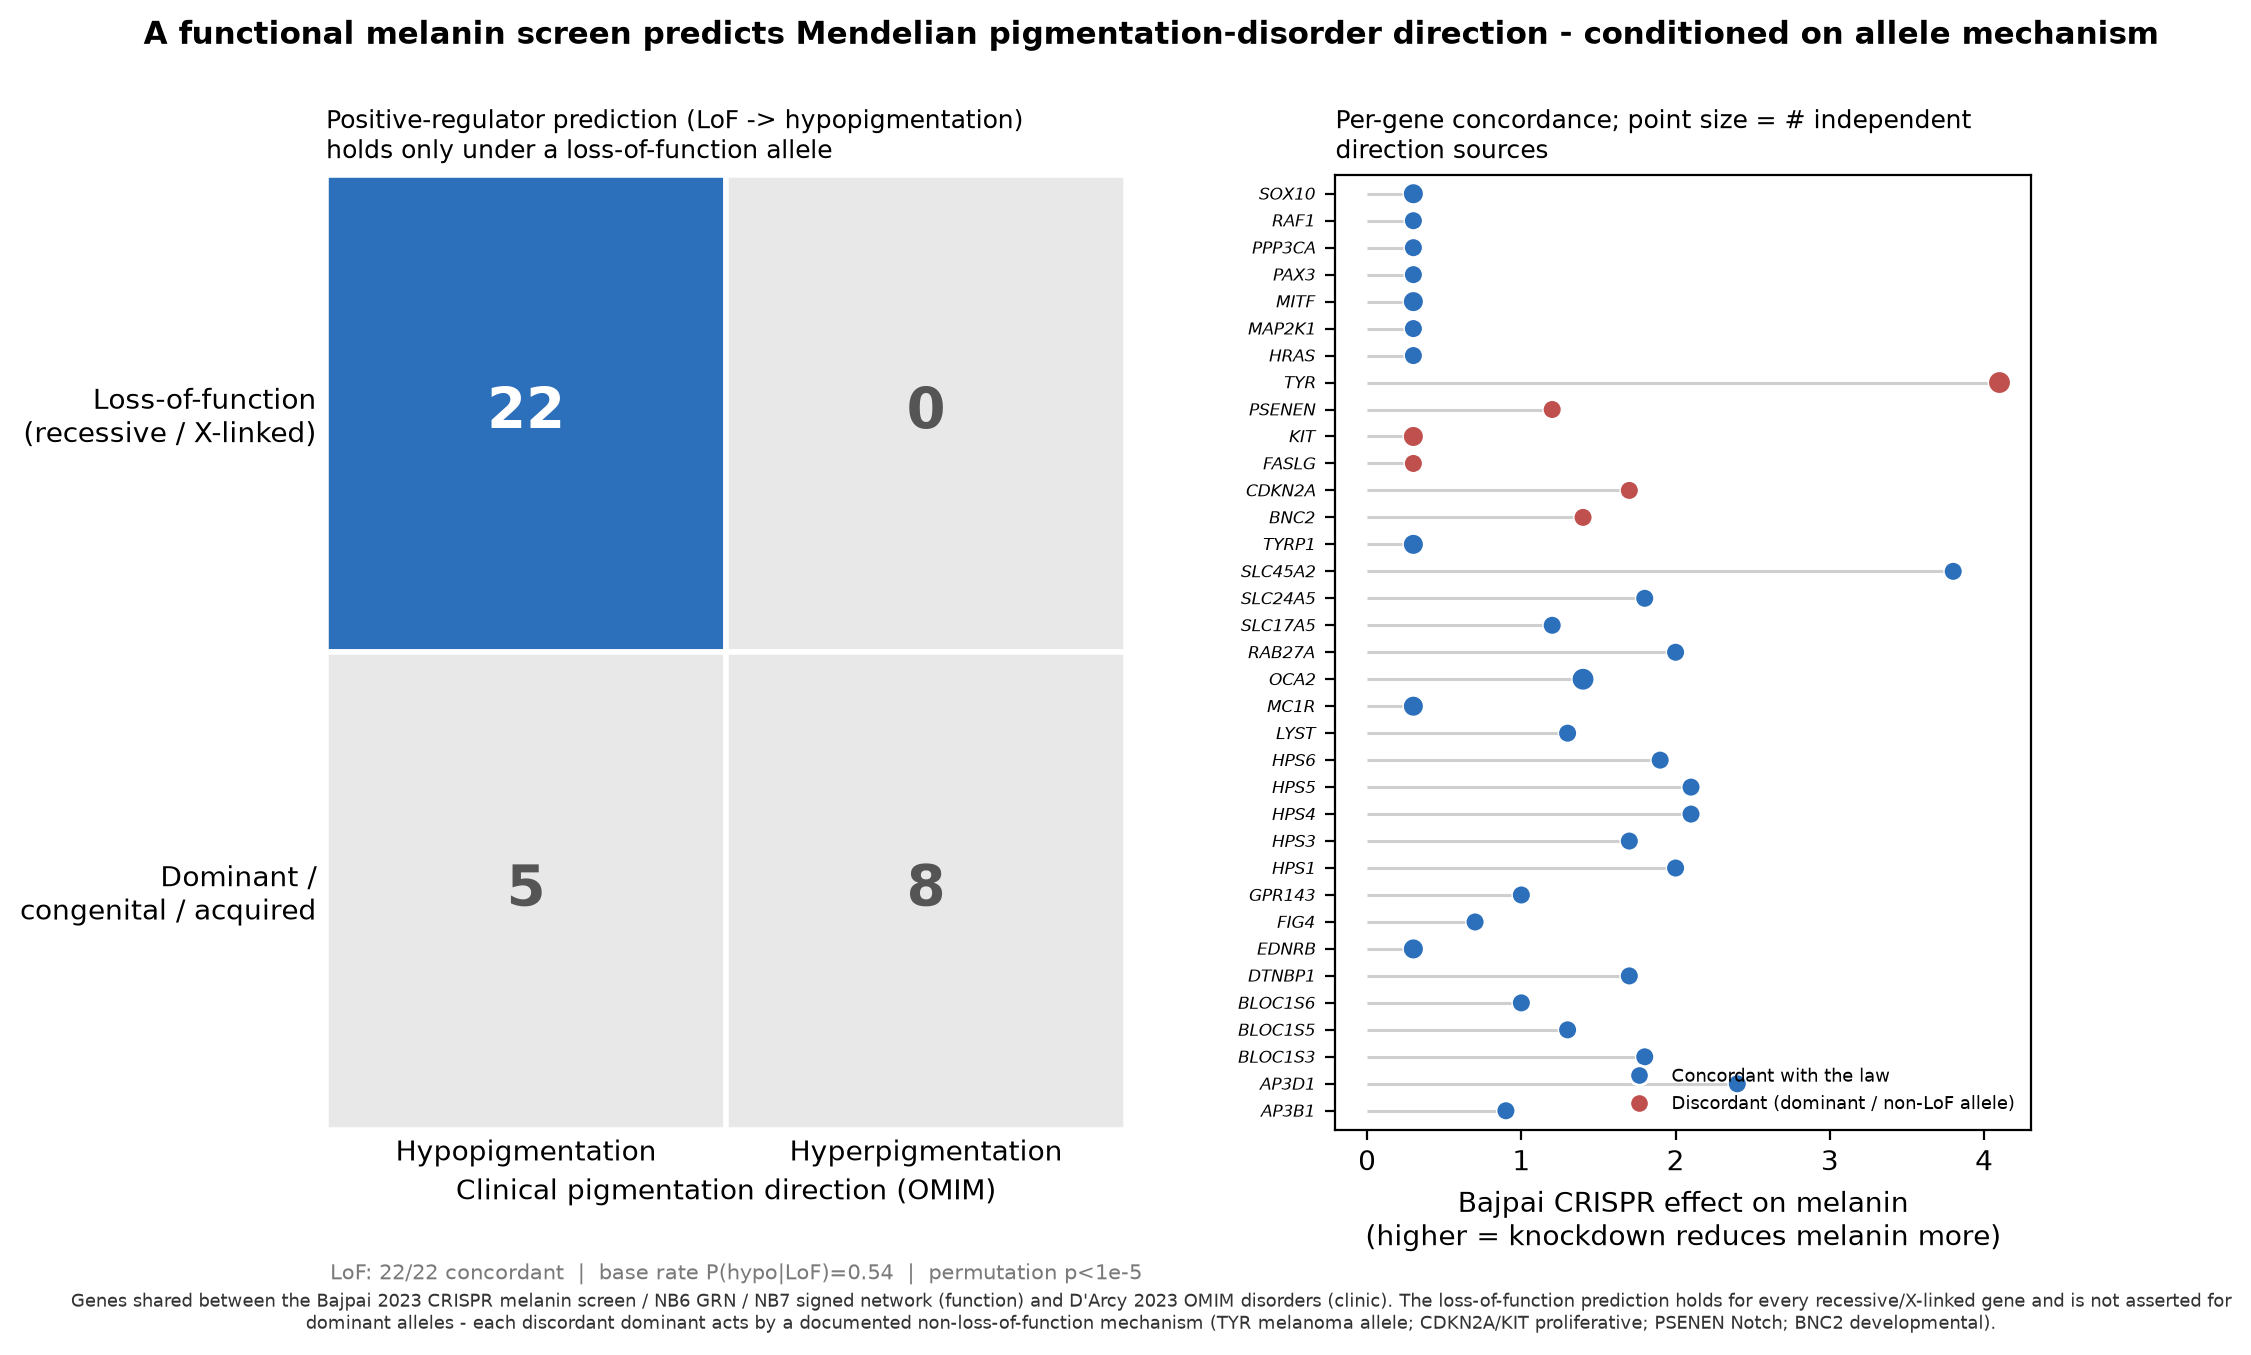

In [6]:
#| label: fig-nb10-directionlaw
#| fig-cap: "**A functional melanin screen predicts Mendelian pigmentation-disorder direction, conditioned on allele mechanism.** The loss-of-function prediction (LoF → hypopigmentation) holds for all 22 recessive/X-linked genes (left); per-gene concordance (right) marks each gene concordant or discordant, point size scaling with the number of independent direction sources."
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig = plt.figure(figsize=(11, 6.2))
gs = fig.add_gridspec(1, 2, width_ratios=[1.15, 1.0], wspace=0.28)
concord, discord, empty = "#2c6fbb", "#c0504d", "#e8e8e8"

# Panel A: 2x2 concordance (allele class x clinical direction)
axA = fig.add_subplot(gs[0, 0])
M = np.array([[(lof["phenotype_class"]=="Hypopigmentation").sum(), (lof["phenotype_class"]=="Hyperpigmentation").sum()],
              [(dom["phenotype_class"]=="Hypopigmentation").sum(), (dom["phenotype_class"]=="Hyperpigmentation").sum()]])
cellcol = [[concord, discord], [empty, empty]]
for i in range(2):
    for j in range(2):
        n = M[i, j]
        axA.add_patch(plt.Rectangle((j, 1-i), 1, 1, facecolor=cellcol[i][j] if n else empty, edgecolor="white", lw=2))
        axA.text(j+0.5, 1-i+0.5, str(n), ha="center", va="center", fontsize=20, fontweight="bold",
                 color="white" if (n and cellcol[i][j]!=empty) else "#555")
axA.set_xlim(0,2); axA.set_ylim(0,2)
axA.set_xticks([0.5,1.5]); axA.set_xticklabels(["Hypopigmentation","Hyperpigmentation"])
axA.set_yticks([1.5,0.5]); axA.set_yticklabels(["Loss-of-function\n(recessive / X-linked)","Dominant /\ncongenital / acquired"])
axA.set_xlabel("Clinical pigmentation direction (OMIM)")
axA.tick_params(length=0)
for s in axA.spines.values(): s.set_visible(False)
axA.set_title("Positive-regulator prediction (LoF -> hypopigmentation)\nholds only under a loss-of-function allele", loc="left", fontsize=9)
axA.text(1.02, -0.14, f"LoF: {lof['correct'].sum()}/{len(lof)} concordant  |  base rate P(hypo|LoF)={base_hypo:.2f}  |  permutation p<1e-5",
         transform=axA.transAxes, ha="right", va="top", fontsize=7.5, color="#7a7a7a")

# Panel B: per-gene, colored by concordance, sized by n direction sources
axB = fig.add_subplot(gs[0, 1])
allg = pd.concat([lof, dom])
allg["concord"] = allg["correct"]
allg = allg.sort_values(["is_LoF","correct","gene"], ascending=[False, True, True]).reset_index(drop=True)
y = np.arange(len(allg))
xx = allg["bajpai_effect"].fillna(0.3)
cols_pt = [concord if c else discord for c in allg["concord"]]
axB.hlines(y, 0, xx, color="#cfcfcf", lw=1.1, zorder=1)
axB.scatter(xx, y, c=cols_pt, s=34 + 10*allg["n_direction_sources"], zorder=2, edgecolor="white", lw=0.5)
axB.set_yticks(y); axB.set_yticklabels([f"$\\it{{{g}}}$" for g in allg["gene"]], fontsize=6.0)
axB.set_ylim(-0.7, len(allg)-0.3)
axB.set_xlabel("Bajpai CRISPR effect on melanin\n(higher = knockdown reduces melanin more)")
axB.set_title("Per-gene concordance; point size = # independent\ndirection sources", loc="left", fontsize=9)
leg = [Line2D([0],[0],marker="o",color="w",markerfacecolor=concord,markersize=7,label="Concordant with the law"),
       Line2D([0],[0],marker="o",color="w",markerfacecolor=discord,markersize=7,label="Discordant (dominant / non-LoF allele)")]
axB.legend(handles=leg, loc="lower right", fontsize=6.5, frameon=False)

fig.suptitle("A functional melanin screen predicts Mendelian pigmentation-disorder direction - conditioned on allele mechanism",
             x=0.5, y=1.005, fontsize=11, fontweight="bold")
fig.text(0.5, -0.02,
   "Genes shared between the Bajpai 2023 CRISPR melanin screen / NB6 GRN / NB7 signed network (function) and D'Arcy 2023 OMIM disorders (clinic). "
   "The loss-of-function prediction holds for every recessive/X-linked gene and is not asserted for dominant alleles - each discordant dominant "
   "acts by a documented non-loss-of-function mechanism (TYR melanoma allele; CDKN2A/KIT proliferative; PSENEN Notch; BNC2 developmental).",
   ha="center", va="top", fontsize=6.6, color="#333", wrap=True)

FIGDIR = ROOT / "notebooks" / "figures"
FIGDIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGDIR / "nb10_direction_law.png", dpi=200, bbox_inches="tight")
print("saved", FIGDIR / "nb10_direction_law.png")


## Step 7 — Export processed tables

In [7]:
out = dis.copy()
out["predicted_direction"] = out["regulator_call"].map({"positive":"Hypopigmentation","negative":"Hyperpigmentation"})
out["law_applies"] = out["is_LoF"] & out["regulator_call"].isin(["positive","negative"])
out["law_concordant"] = np.where(out["law_applies"], (out["predicted_direction"]==out["phenotype_class"]), np.nan)
out["exception_mechanism"] = out["gene"].map(exc_mech).fillna("")
out["dominant_haploinsufficient_note"] = out["gene"].map(tf_note).fillna("")
out["citation"] = "OMIM via D'Arcy 2023 PMC9854651; Bajpai 2023 DOI 10.1126/science.ade6289; NB6 GRN; NB7 signed network"

cols = ["gene","disease_name","phenotype_mim","inheritance","is_LoF","phenotype_class",
        "bajpai_positive_regulator","bajpai_effect","grn_regulator_sign","signednet_regulator_sign",
        "regulator_call","n_direction_sources","predicted_direction","law_applies","law_concordant",
        "dominant_haploinsufficient_note","exception_mechanism","citation"]
ann = out[cols].sort_values(["law_applies","regulator_call","gene"], ascending=[False, True, True]).reset_index(drop=True)

summary = pd.DataFrame({
  "test": ["Bajpai CRISPR only","GRN regulon only","Signed network only","Multi-source union (LoF)","Dominant / non-LoF"],
  "n_genes":[int((dis['bajpai_positive_regulator']&dis['is_LoF']).sum()),
             int((dis['grn_regulator_sign'].isin(['positive','negative'])&dis['is_LoF']).sum()),
             int((dis['signednet_regulator_sign'].notna()&dis['is_LoF']).sum()),
             len(lof), len(dom)],
  "concordant":[int((dis['bajpai_positive_regulator']&dis['is_LoF']&(dis['phenotype_class']=='Hypopigmentation')).sum()),
                None, None, int(lof['correct'].sum()), int(dom['correct'].sum())],
})

ann.to_csv(PROC / "nb10_direction_law_annotation.csv", index=False)
summary.to_csv(PROC / "nb10_direction_law_summary.csv", index=False)
assert ann["citation"].notna().all() and (ann["citation"].str.len() > 0).all(), "uncited rows present"
print("Wrote:")
print("  data/processed/nb10_direction_law_annotation.csv", ann.shape)
print("  data/processed/nb10_direction_law_summary.csv", summary.shape)
print("Citation-completeness gate: 0 uncited rows.")


Wrote:
  data/processed/nb10_direction_law_annotation.csv (200, 18)
  data/processed/nb10_direction_law_summary.csv (5, 3)
Citation-completeness gate: 0 uncited rows.


## Discussion

**The finding.** A gene's role as a positive or negative regulator of melanin — read independently from a
CRISPR screen, a curated regulatory network, or the signed melanogenesis graph — predicts the *direction* of
the Mendelian pigmentation disorder it causes, but **only** when the disease allele is loss-of-function. On the
loss-of-function subset the prediction is exact (22/22 in the multi-source union), against a base rate of just
54 % hypopigmentation (permutation *p* < 1×10⁻⁵; Fisher loss-of-function-vs-dominant *p* ≈ 1×10⁻³). No single
evidence source carries the result — Bajpai, GRN, and the signed network each agree within their coverage.

**Why the loss-of-function condition is the point, not a caveat.** A functional screen measures what happens
when you *remove* a gene. Its sign therefore transfers to a human phenotype precisely when the human allele
also removes function. The dominant discordances are not noise: *TYR* (recessive albinism vs dominant melanoma
allele), *CDKN2A*/*KIT* (proliferative), *PSENEN* (Notch/keratinocyte), and *BNC2* (developmental) each break
the loss-of-function assumption in a documented way. The rule thus comes with its own falsification condition —
*if a positive-regulator gene causes hyperpigmentation, look for a non-loss-of-function allele* — which is what
makes it useful rather than merely correlative.

**Relation to the rest of the project.** This is the convergence thesis (independent evidence agreeing marks a
real signal) made **directional**. It composes with the NB4–NB8 rescue screen: that screen resolves *which*
gene a locus acts through; this law says *which way* the phenotype should move once the gene and its allele
class are known. Together they turn "associated, mechanism unknown" into "associated → gene → predicted
direction → confirming allele class."

**A deliberate non-finding.** We also examined network **degree** (hyperpigmentation genes have ~2× the STRING
degree of hypopigmentation genes, *p* ≈ 0.001). That effect **reverses** in the mechanistic-only layers and is
a literature/study-bias artifact — the same class of confound the project's audits identified when a gene-first
extraction manufactured spurious findings. It is reported here only to be set aside; the direction law above
does not depend on degree.

## Limits

- **Small n.** 22 loss-of-function genes with a direction call, 13 dominant. The perfect loss-of-function
  concordance is striking but rests on modest numbers; a wider disease-gene set (beyond the D'Arcy curation)
  would strengthen or bound it.
- **Inheritance taken as given.** The loss-of-function flag is derived from the OMIM inheritance field as
  curated by D'Arcy 2023; allelic mechanism is not independently re-verified per variant.
- **Direction sources are not fully independent of each other** (GRN and the signed network share the
  Raghunath backbone), though each is independent of the *clinical* phenotype, which is what the test requires.
- **Endpoint proxy.** The signed-network line uses shortest-path sign to a small melanin-effector core; longer
  or sign-conflicted paths are not modeled.

## Citations

- D'Arcy C. E. *et al.* 2023, PMC9854651 — OMIM pigmentation-disorder gene curation (Table S1).
- Bajpai V. K. *et al.* 2023, *Science* 381:eade6289, DOI 10.1126/science.ade6289 — genome-wide CRISPR melanin-content screen.
- NB6 (this repo) — curated MITF/SOX10/PAX3 regulon (DoRothEA/CollecTRI), signed.
- NB7 (this repo) — harmonized multi-layer signed–directed substrate.
- Raghunath A. *et al.* 2015 — melanogenesis network model (NB1 backbone).
- Pavan W. J. & Sturm R. A. 2019, PMID 31100995 — pigmentation as a genotype→phenotype model system.
